# 프로젝트 대비 연습: Pima 당뇨병 데이터 분류

## 오늘의 목표

지금까지 분류([1. classification.ipynb](../../day1/4.%20분류/1.%20classification.ipynb)), 오류·SHAP 분석([3. XAI.ipynb](../../day1/4.%20분류/3.%20XAI.ipynb)), 트리와 앙상블([1. Tree.ipynb](1.%20Tree.ipynb))에서 배운 내용을 하나의 새 데이터에 이어서 적용해봅니다.

**EDA → 베이스 모델 학습 → 원인 분석 → 개선 시도 → 결과 확인 → 원인 분석 → 개선 시도 → 앙상블** 순서로 진행합니다. 모든 시도가 성능을 높이는 것은 아닙니다. 시도한 이유와 실제로 나온 결과를 함께 확인하는 데 집중합니다.

사용할 데이터는 **Pima 인디언 여성(21세 이상) 768명의 건강검진 기록**이며, `Outcome`은 당뇨병 진단 여부(0: 음성, 1: 양성)입니다.

## 1. EDA — 데이터 살펴보기

| 입력 항목 | 의미 · 단위 |
|---|---|
| Pregnancies | 임신 횟수(회) |
| Glucose | 경구 포도당 부하 검사 2시간 후 혈당(mg/dL) |
| BloodPressure | 이완기 혈압(mm Hg) |
| SkinThickness | 삼두근 피부 주름 두께(mm) |
| Insulin | 혈청 인슐린(mu U/ml) |
| BMI | 체질량지수(kg/m²) |
| DiabetesPedigreeFunction | 가족력 기반 당뇨병 발병 가능성 점수 |
| Age | 나이(세) |
| Outcome | 당뇨병 여부: 음성 0, 양성 1 |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

df = pd.read_csv("diabetes.csv")
print(f"행: {df.shape[0]}, 열: {df.shape[1]}")
display(df.head())

행: 768, 열: 9


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


정답 비율부터 확인합니다.

In [2]:
outcome_counts = df["Outcome"].value_counts()
outcome_ratio = df["Outcome"].value_counts(normalize=True)
display(pd.DataFrame({"명": outcome_counts, "비율(%)": (outcome_ratio * 100).round(1)}))

,명,비율(%)
Outcome,,
0,500,65.1
1,268,34.9


음성이 양성보다 약 2배 많습니다(65.1% vs 34.9%). 이어서 각 항목의 최솟값 · 최댓값이 그럴듯한 범위에 있는지 봅니다.

In [3]:
display(df.describe().round(1))

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.0,768.0,768.0,768.0,768.0,768.0,768.0,768.0,768.0
mean,3.8,120.9,69.1,20.5,79.8,32.0,0.5,33.2,0.3
std,3.4,32.0,19.4,16.0,115.2,7.9,0.3,11.8,0.5
min,0.0,0.0,0.0,0.0,0.0,0.0,0.1,21.0,0.0
25%,1.0,99.0,62.0,0.0,0.0,27.3,0.2,24.0,0.0
50%,3.0,117.0,72.0,23.0,30.5,32.0,0.4,29.0,0.0
75%,6.0,140.2,80.0,32.0,127.2,36.6,0.6,41.0,1.0
max,17.0,199.0,122.0,99.0,846.0,67.1,2.4,81.0,1.0


Glucose(혈당), BloodPressure(혈압), SkinThickness(피부 두께), Insulin(인슐린), BMI(체질량지수)의 최솟값이 모두 0입니다. 혈당이나 혈압이 실제로 0인 사람은 없으므로, 검사하지 않았거나 기록되지 않은 값이 0으로 입력됐을 가능성이 있습니다. 곧바로 지우거나 바꾸지 않고, 먼저 몇 명에게서 이런 값이 나타나는지 살펴봅니다.

In [4]:
zero_like_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

zero_counts = pd.DataFrame({
    "0으로 기록된 행(명)": (df[zero_like_cols] == 0).sum(),
    "비율(%)": ((df[zero_like_cols] == 0).mean() * 100).round(1),
})
display(zero_counts)

,0으로 기록된 행(명),비율(%)
Glucose,5,0.7
BloodPressure,35,4.6
SkinThickness,227,29.6
Insulin,374,48.7
BMI,11,1.4


Insulin은 절반 가까이(48.7%), SkinThickness는 세 명 중 한 명꼴(29.6%)로 0입니다. Glucose · BMI는 1% 안팎으로 적습니다. 이 값들은 일단 그대로 두고, 각 항목이 정답(Outcome) 및 서로와 얼마나 관련이 있는지 상관관계로 살펴봅니다.

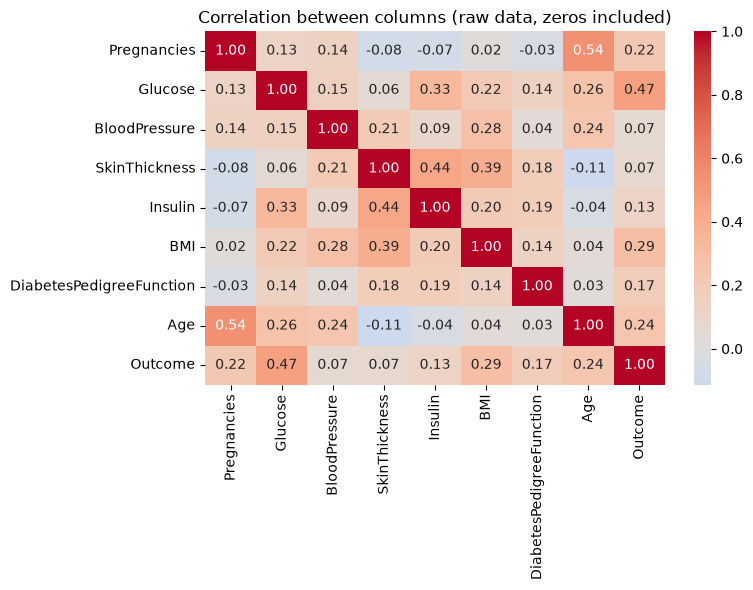

Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64

In [5]:
import seaborn as sns

corr = df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation between columns (raw data, zeros included)")
plt.tight_layout()
plt.show()

corr["Outcome"].sort_values(ascending=False)

Outcome과 가장 관련이 큰 항목은 Glucose(0.47)이고, BMI(0.29) · Age(0.24)가 뒤를 잇습니다. SkinThickness · BloodPressure는 0.1 미만으로 관련이 약합니다. 입력 항목끼리도 관련이 있는 경우가 있는데, 예를 들어 Pregnancies와 Age는 0.54로 다른 조합보다 뚜렷하게 높습니다. Outcome과 가장 관련이 컸던 두 항목, Glucose와 BMI를 함께 산점도로 봅니다.

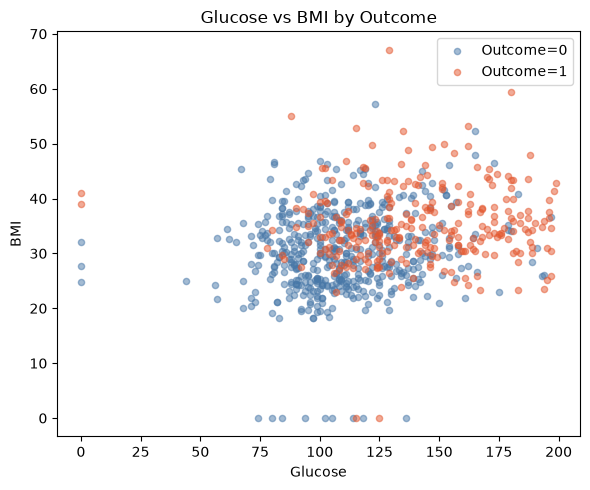

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
for outcome, color in zip([0, 1], ["#4878A8", "#E4572E"]):
    subset = df.loc[df["Outcome"] == outcome]
    ax.scatter(subset["Glucose"], subset["BMI"], alpha=0.5, label=f"Outcome={outcome}", color=color, s=20)
ax.set(title="Glucose vs BMI by Outcome", xlabel="Glucose", ylabel="BMI")
ax.legend()
plt.tight_layout()
plt.show()

양성(주황)이 대체로 오른쪽 위(혈당 · 체질량지수가 모두 높은 쪽)에 더 많이 몰려 있지만, 겹치는 영역도 넓어 이 두 값만으로 깔끔하게 나뉘지는 않습니다. 상관계수가 가장 높았던 Glucose 하나만 떼어서 분포를 조금 더 자세히 봅니다.

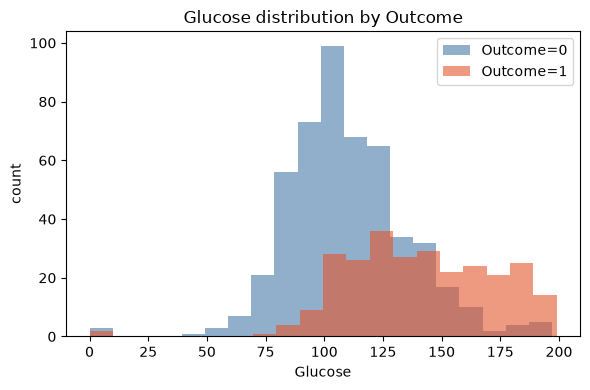

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
for outcome, color in zip([0, 1], ["#4878A8", "#E4572E"]):
    subset = df.loc[df["Outcome"] == outcome, "Glucose"]
    ax.hist(subset, bins=20, alpha=0.6, label=f"Outcome={outcome}", color=color)
ax.set(title="Glucose distribution by Outcome", xlabel="Glucose", ylabel="count")
ax.legend()
plt.tight_layout()
plt.show()

양성 쪽 분포가 음성보다 오른쪽으로 치우쳐 있지만 겹치는 구간이 여전히 넓습니다. 상관계수 0.47은 중간 정도 강도이므로, Glucose 하나만으로 깔끔하게 나뉘지 않는 것은 자연스러운 결과입니다. 이 겹치는 구간의 환자들을 모델이 어떻게 판단하는지 베이스 모델을 학습한 뒤 확인합니다.

## 2. 베이스 모델 학습

0으로 기록된 값을 일단 그대로 두고, 결정 트리로 첫 모델을 학습합니다. 평가용 자료는 전체의 20%를 무작위로 떼어둡니다(`stratify`로 두 자료의 양성 비율을 맞춥니다). 트리 깊이는 [1. Tree.ipynb](1.%20Tree.ipynb)와 같은 이유로 `max_depth=4`로 제한합니다.

,베이스 모델
정확도,0.799
정밀도,0.745
재현율,0.648
F1,0.693


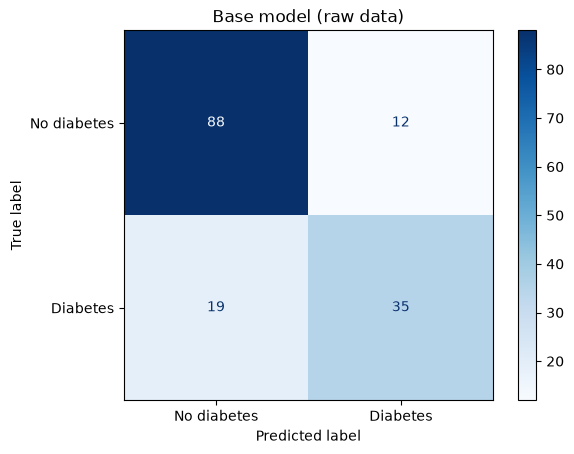

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

y = df["Outcome"]
X = df.drop(columns=["Outcome"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


def metrics(y_true, y_pred_):
    return {
        "정확도": accuracy_score(y_true, y_pred_),
        "정밀도": precision_score(y_true, y_pred_),
        "재현율": recall_score(y_true, y_pred_),
        "F1": f1_score(y_true, y_pred_),
    }


base_metrics = metrics(y_test, y_pred)
display(pd.DataFrame({"베이스 모델": base_metrics}).round(3))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["No diabetes", "Diabetes"], cmap="Blues")
plt.title("Base model (raw data)")
plt.show()

정확도는 0.799지만 재현율은 0.648로 더 낮습니다. 실제 양성 환자 중 상당수를 놓치고 있다는 뜻이며, 혼동행렬에서도 실제 양성을 음성으로 예측한 칸(FN)이 19명으로 나타납니다. 트리가 어떤 항목을 기준으로 이렇게 판단했는지 변수 중요도와 첫 번째 분기 기준으로 확인합니다.

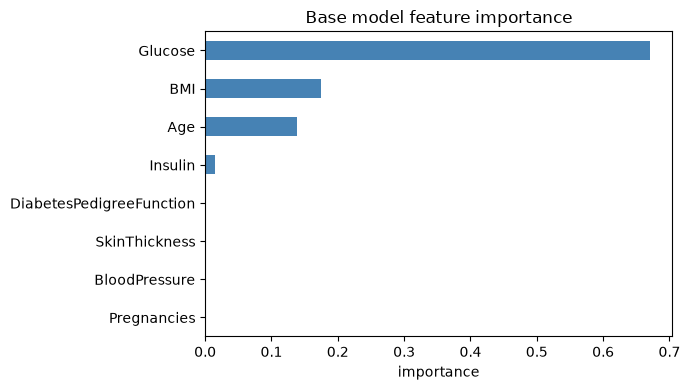

Glucose                     0.671
BMI                         0.175
Age                         0.139
Insulin                     0.016
DiabetesPedigreeFunction    0.000
SkinThickness               0.000
BloodPressure               0.000
Pregnancies                 0.000
dtype: float64

트리의 첫 두 단계 분기 기준:
|--- Glucose <= 154.50
|   |--- BMI <= 27.35
|   |   |--- truncated branch of depth 3
|   |--- BMI >  27.35
|   |   |--- truncated branch of depth 3
|--- Glucose >  154.50
|   |--- BMI <= 23.10
|   |   |--- class: 0
|   |--- BMI >  23.10
|   |   |--- truncated branch of depth 3



In [9]:
from sklearn.tree import export_text

importances = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=True)
importances.plot(kind="barh", figsize=(7, 4), color="steelblue")
plt.title("Base model feature importance")
plt.xlabel("importance")
plt.tight_layout()
plt.show()
print(importances.sort_values(ascending=False).round(3))

print("\n트리의 첫 두 단계 분기 기준:")
print(export_text(model, feature_names=list(X_train.columns), max_depth=1))

Glucose 하나가 중요도의 67%를 차지합니다. BMI(17%), Age(14%)가 그 다음이고, Insulin은 2%뿐이며 SkinThickness · BloodPressure · Pregnancies · DiabetesPedigreeFunction은 이번 트리에서 전혀 쓰이지 않았습니다(중요도 0). 트리의 첫 번째 분기도 `Glucose <= 154.50`으로, 혈당이 판단의 출발점입니다.

## 3. 원인 분석 — 실제 양성을 왜 놓쳤을까

재현율이 낮다는 것은 실제 양성 환자 중 놓친 사람이 많다는 뜻입니다. 맞춘 양성과 놓친 양성을 나눠 정보를 비교합니다.

In [10]:
results = X_test.copy()
results["실제"] = y_test
results["예측"] = y_pred
results["결과"] = np.select(
    [(results["실제"] == 1) & (results["예측"] == 1),
     (results["실제"] == 1) & (results["예측"] == 0),
     (results["실제"] == 0) & (results["예측"] == 1)],
    ["맞춘 양성(TP)", "놓친 양성(FN)", "오판(FP)"],
    default="맞춘 음성(TN)",
)

print(results["결과"].value_counts())
display(results.groupby("결과")[["Glucose", "BMI", "Age"]].mean().round(1))

결과
맞춘 음성(TN)    88
맞춘 양성(TP)    35
놓친 양성(FN)    19
오판(FP)       12
Name: count, dtype: int64


,Glucose,BMI,Age
결과,,,
놓친 양성(FN),119.8,33.7,31.6
맞춘 양성(TP),151.0,35.5,38.9
맞춘 음성(TN),104.5,29.9,29.5
오판(FP),154.4,35.4,40.5


놓친 양성(FN) 19명의 평균 혈당은 119.8로, 맞춘 양성(TP) 35명의 평균 151.0보다 30 가까이 낮습니다. 트리의 첫 분기 기준이 `Glucose <= 154.50`이었던 것을 생각하면, 혈당이 그보다 한참 낮은 양성 환자는 '양성' 쪽 가지로 가지 못하고 놓치는 경향이 있다고 볼 수 있습니다.

이와는 별개로, 모델이 Insulin이나 SkinThickness 같은 다른 정보는 거의 쓰지 못하고 있습니다. 앞서 이 두 항목이 각각 48.7%, 29.6%가 0으로 기록되어 있었던 것을 떠올리면, 그 잡음 때문에 트리가 해당 항목들을 신뢰하지 못했을 가능성이 있습니다. 이 가설을 확인하기 위해 0을 결측치로 보고 채운 뒤 같은 모델을 다시 학습해 비교합니다.

## 4. 개선 시도 1 — 0을 결측치로 보고 채우기

Glucose, BloodPressure, SkinThickness, Insulin, BMI의 0을 결측치로 바꾸고, **학습 자료의 중앙값**으로 채웁니다. 평가 자료도 학습 자료에서 구한 값으로 채웁니다(평가 정보를 미리 들여다보지 않기 위해). 모델 종류 · 설정 · 평가 방법은 베이스 모델과 동일하게 유지합니다.

In [11]:
X_train_filled = X_train.copy()
X_test_filled = X_test.copy()

fill_values = {}
for col in zero_like_cols:
    X_train_filled[col] = X_train_filled[col].replace(0, np.nan)
    X_test_filled[col] = X_test_filled[col].replace(0, np.nan)
    median = X_train_filled[col].median()
    fill_values[col] = median
    X_train_filled[col] = X_train_filled[col].fillna(median)
    X_test_filled[col] = X_test_filled[col].fillna(median)

display(pd.DataFrame({"채울 값(학습 자료 중앙값)": fill_values}))

sample_idx = X_test.index[(X_test[zero_like_cols] == 0).any(axis=1)][:3]
display(pd.concat(
    {"채우기 전": X_test.loc[sample_idx, zero_like_cols],
     "채운 후": X_test_filled.loc[sample_idx, zero_like_cols]},
    axis=1,
))

,채울 값(학습 자료 중앙값)
Glucose,117.0
BloodPressure,72.0
SkinThickness,29.0
Insulin,125.0
BMI,32.4


채우기 전                                              채운 후                \
    Glucose BloodPressure SkinThickness Insulin   BMI Glucose BloodPressure   
44      159            64             0       0  27.4   159.0          64.0   
630     114            64             0       0  27.4   114.0          64.0   
81       74             0             0       0   0.0    74.0          72.0   

                                 
    SkinThickness Insulin   BMI  
44           29.0   125.0  27.4  
630          29.0   125.0  27.4  
81           29.0   125.0  32.4

In [12]:
model_filled = DecisionTreeClassifier(max_depth=4, random_state=42)
model_filled.fit(X_train_filled, y_train)
y_pred_filled = model_filled.predict(X_test_filled)

filled_metrics = metrics(y_test, y_pred_filled)
display(pd.DataFrame({"베이스 모델": base_metrics, "개선 시도 1 (결측치 채움)": filled_metrics}).round(3))

,베이스 모델,개선 시도 1 (결측치 채움)
정확도,0.799,0.786
정밀도,0.745,0.698
재현율,0.648,0.685
F1,0.693,0.692


## 5. 결과 확인 — 개선 전후 비교

전체 지표와, 앞서 관심을 둔 놓친 양성(FN) · 오판(FP) 수를 함께 봅니다.

In [13]:
results_filled = X_test_filled.copy()
results_filled["실제"] = y_test
results_filled["예측"] = y_pred_filled

fn_before = int(((results["실제"] == 1) & (results["예측"] == 0)).sum())
fn_after = int(((results_filled["실제"] == 1) & (results_filled["예측"] == 0)).sum())
fp_before = int(((results["실제"] == 0) & (results["예측"] == 1)).sum())
fp_after = int(((results_filled["실제"] == 0) & (results_filled["예측"] == 1)).sum())

display(pd.DataFrame({
    "개선 전": {"놓친 양성(FN, 명)": fn_before, "오판(FP, 명)": fp_before, **base_metrics},
    "개선 후": {"놓친 양성(FN, 명)": fn_after, "오판(FP, 명)": fp_after, **filled_metrics},
}).round(3))

,개선 전,개선 후
"놓친 양성(FN, 명)",19.000,17.000
"오판(FP, 명)",12.000,16.000
정확도,0.799,0.786
정밀도,0.745,0.698
재현율,0.648,0.685
F1,0.693,0.692


놓친 양성은 19명에서 17명으로 줄고 재현율은 0.648→0.685로 올랐습니다. 하지만 오판(FP)이 12명에서 16명으로 늘면서 정밀도(0.745→0.698)와 정확도(0.799→0.786)는 오히려 내려갔습니다. 한쪽 오류를 줄이는 대신 다른 쪽 오류가 늘어난, 뚜렷한 개선이라 보기 어려운 결과입니다. 그래도 처음 목표로 삼았던 '놓친 양성 줄이기' 방향과는 맞았으므로, 남은 오류를 다시 살펴봅니다.

## 6. 원인 분석 — 남은 오류와 클래스 비율

개선 후에도 남아 있는 오류가 앞서 본 것과 같은 패턴인지, 앞서 세운 가설(잡음 때문에 다른 항목을 못 쓴다)이 실제로 맞았는지 확인합니다.

In [14]:
results_filled["결과"] = np.select(
    [(results_filled["실제"] == 1) & (results_filled["예측"] == 1),
     (results_filled["실제"] == 1) & (results_filled["예측"] == 0),
     (results_filled["실제"] == 0) & (results_filled["예측"] == 1)],
    ["맞춘 양성(TP)", "놓친 양성(FN)", "오판(FP)"],
    default="맞춘 음성(TN)",
)
display(results_filled.groupby("결과")[["Glucose", "BMI", "Age"]].mean().round(1))

filled_importances = pd.Series(model_filled.feature_importances_, index=X_train_filled.columns)
print(filled_importances.sort_values(ascending=False).round(3))

,Glucose,BMI,Age
결과,,,
놓친 양성(FN),121.2,35.8,31.6
맞춘 양성(TP),148.6,34.4,38.5
맞춘 음성(TN),104.3,30.7,29.0
오판(FP),150.5,33.9,40.4


Glucose                     0.670
BMI                         0.168
Age                         0.119
Insulin                     0.043
SkinThickness               0.000
BloodPressure               0.000
Pregnancies                 0.000
DiabetesPedigreeFunction    0.000
dtype: float64


결측치를 채운 뒤에도 놓친 양성(FN)의 평균 혈당은 121.2로 여전히 맞춘 양성(TP) 148.6보다 낮고, 평균 나이도 31.6세로 TP(38.5세)보다 어립니다. 혈당이 애매하게 낮은, 비교적 젊은 양성 환자를 놓치는 경향은 그대로 남아 있습니다.

앞서 세운 가설은 절반만 맞았습니다. Insulin의 중요도는 0.016에서 0.043으로 조금 늘었지만, SkinThickness는 여전히 0입니다. Glucose도 67%로 거의 그대로여서, 0을 채운 것만으로는 트리가 다른 정보를 적극적으로 활용하게 만들지 못했습니다.

결정 트리는 기본적으로 전체 오차(불순도)를 최소화하도록 학습됩니다. 양성이 전체의 35%뿐이라서, 애매한 환자 몇 명을 음성으로 잘못 판단해도 전체 정확도에 큰 타격이 없다면 트리는 이를 크게 신경 쓰지 않을 수 있습니다. 이번에는 학습 방식 자체를 바꿔, 양성을 놓치는 오류에 더 큰 비중을 주고 다시 학습해봅니다.

## 7. 개선 시도 2 — 양성 오류에 가중치 주기

`class_weight="balanced"`로 설정하면, 트리는 학습 중 각 클래스 비율의 역수만큼 오류에 가중치를 곱해서 계산합니다. 양성이 음성보다 적으므로 양성을 틀리는 오류가 더 크게 반영됩니다. 데이터 · 평가 방법 · 나머지 설정은 개선 시도 1과 그대로 두고 이 옵션만 추가합니다.

,개선 시도 1,개선 시도 2 (class_weight)
정확도,0.786,0.708
정밀도,0.698,0.556
재현율,0.685,0.833
F1,0.692,0.667


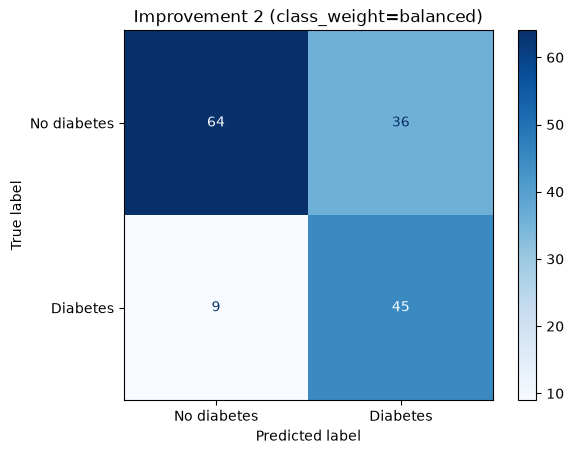

In [15]:
model_balanced = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight="balanced")
model_balanced.fit(X_train_filled, y_train)
y_pred_balanced = model_balanced.predict(X_test_filled)

balanced_metrics = metrics(y_test, y_pred_balanced)
display(pd.DataFrame({
    "개선 시도 1": filled_metrics,
    "개선 시도 2 (class_weight)": balanced_metrics,
}).round(3))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_balanced, display_labels=["No diabetes", "Diabetes"], cmap="Blues")
plt.title("Improvement 2 (class_weight=balanced)")
plt.show()

재현율은 0.685→0.833으로 크게 올라 놓친 양성이 17명에서 9명으로 줄었습니다. 하지만 정밀도는 0.698→0.556, 정확도는 0.786→0.708로 함께 떨어졌고 오판(FP)은 16명에서 36명으로 늘었습니다. 재현율은 확실히 개선했지만 정확도 · 정밀도를 크게 낮추는 대가를 치른 트레이드오프입니다. 당뇨병 선별 검사처럼 양성을 놓치지 않는 것이 중요한 상황이라면 받아들여질 수 있지만, 오판이 늘었다는 사실도 함께 봐야 합니다.

## 8. 앙상블 — 여러 모델을 함께 비교하기

지금까지 결정 트리 하나로 두 가지 개선을 시도했습니다. 이번에는 여러 트리를 합친 랜덤포레스트, 순차적으로 오차를 보완하는 XGBoost, 그리고 서로 다른 모델을 직접 묶은 Voting을 함께 비교합니다. 모두 결측치를 채운 자료(개선 시도 1)를 사용하고, `class_weight="balanced"`를 적용한 버전도 함께 비교해 앞서 본 극단적인 트레이드오프가 앙상블에서는 어떻게 달라지는지 봅니다.

In [16]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

rf_balanced = RandomForestClassifier(n_estimators=200, max_depth=4, random_state=42, class_weight="balanced")
xgb_model = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42, eval_metric="logloss")
voting_balanced = VotingClassifier(
    estimators=[
        ("logreg", LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")),
        ("tree", DecisionTreeClassifier(max_depth=4, random_state=42, class_weight="balanced")),
        ("rf", RandomForestClassifier(n_estimators=200, max_depth=4, random_state=42, class_weight="balanced")),
    ],
    voting="soft",
)

candidates = {
    "결정 트리 (개선 시도 1)": model_filled,
    "결정 트리 (개선 시도 2, balanced)": model_balanced,
    "랜덤포레스트 (balanced)": rf_balanced,
    "XGBoost": xgb_model,
    "Voting (balanced)": voting_balanced,
}

comparison = {}
for name, m in candidates.items():
    m.fit(X_train_filled, y_train)
    pred = m.predict(X_test_filled)
    comparison[name] = metrics(y_test, pred)

display(pd.DataFrame(comparison).T.round(3))

,정확도,정밀도,재현율,F1
결정 트리 (개선 시도 1),0.786,0.698,0.685,0.692
"결정 트리 (개선 시도 2, balanced)",0.708,0.556,0.833,0.667
랜덤포레스트 (balanced),0.734,0.592,0.778,0.672
XGBoost,0.766,0.680,0.630,0.654
Voting (balanced),0.734,0.592,0.778,0.672


가장 높은 정확도 · 정밀도는 결정 트리(개선 시도 1)가, 가장 높은 재현율은 결정 트리(개선 시도 2, balanced)가 기록했습니다. 랜덤포레스트(balanced)와 Voting(balanced)은 두 극단의 중간에 자리합니다 — 재현율(0.778)은 balanced 트리(0.833)보다 조금 낮지만, 정밀도(0.592)와 정확도(0.734)는 더 안정적으로 유지됩니다. 여러 모델을 묶는다고 항상 가장 좋은 점수가 나오는 것은 아니지만, 한 모델의 극단적인 트레이드오프를 완화하는 효과는 이번 비교에서 실제로 확인할 수 있었습니다.

## 정리

| 시도 | 무엇을 했나 | 결과 |
|---|---|---|
| 베이스 모델 | 0을 그대로 둔 결정 트리(depth=4) | 정확도 0.799, 재현율 0.648 |
| 개선 시도 1 | 5개 항목의 0을 결측치로 보고 중앙값으로 채움 | 재현율 0.685로 상승, 정확도 0.786으로 하락 |
| 개선 시도 2 | `class_weight="balanced"`로 양성 오류에 가중치 | 재현율 0.833으로 크게 상승, 정확도 0.708로 크게 하락 |
| 앙상블 | 랜덤포레스트 · XGBoost · Voting 비교 | balanced 앙상블이 트레이드오프를 완화(재현율 0.778, 정확도 0.734) |

어떤 모델을 최종적으로 고를지는 정확도 하나가 아니라, 이 예측을 어디에 쓸 것인지(예: 정밀 검사 전 1차 선별인지, 최종 진단 보조인지)에 따라 달라집니다.